In [2]:
!pip install -q --force-reinstall --no-deps git+https://github.com/RayenSansa03/aeroguard.git

from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from aeroguard.donnees_ml import preparer_xy
from aeroguard.evaluation import ajouter_au_leaderboard, appliquer_seuil, taux_par_classe

DOSSIER = "/content/drive/MyDrive/aeroguard"
LEADERBOARD = f"{DOSSIER}/results/leaderboard.csv"

vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
X_train, y_train = preparer_xy(vols, "train")
X_val, y_val = preparer_xy(vols, "val")
print(X_train.shape, X_val.shape)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Mounted at /content/drive
(3716, 126) (819, 126)


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

logistique = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logistique.fit(X_train, y_train)

probas = logistique.predict_proba(X_val)[:, 1]      # colonne 1 = probabilité « usé »
pred = appliquer_seuil(probas, seuil=0.5)
print(taux_par_classe(y_val, pred))

{'exactitude': 0.9047619047619048, 'uses_detectes': 0.9321739130434783, 'sains_reconnus': 0.8401639344262295}


In [4]:
apercu = vols[vols["groupe"] == "val"][["moteur", "cycle", "RUL"]].copy()
apercu["vrai"] = y_val.values
apercu["proba_use"] = probas.round(2)
apercu["predit"] = pred
apercu.sample(10, random_state=1).sort_values("RUL", ascending=False)

,moteur,cycle,RUL,vrai,proba_use,predit
8,DS01_1,9,91,0,0.09,0
17,DS01_1,18,82,0,0.07,0
1204,DS02_18,2,69,0,0.46,0
1909,DS03_6,3,60,0,0.48,0
1917,DS03_6,11,52,0,0.45,0
5969,DS08a_1,44,28,1,0.99,1
1941,DS03_6,35,28,1,1.00,1
7154,DS08c_5,29,21,1,1.00,1
81,DS01_1,82,18,1,1.00,1
1257,DS02_18,55,16,1,1.00,1


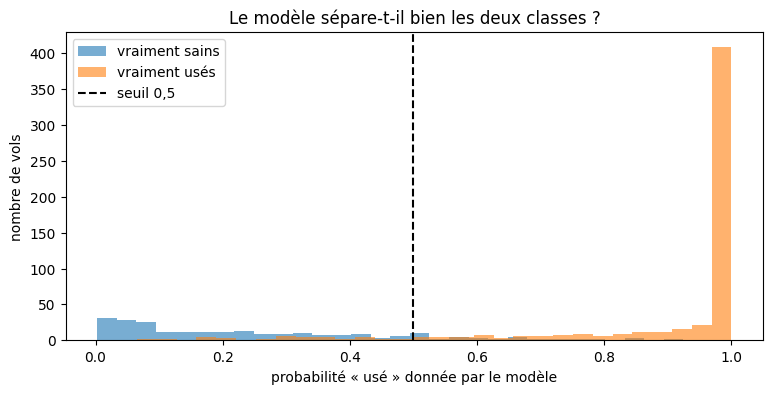

In [5]:
plt.figure(figsize=(9, 4))
plt.hist(probas[y_val == 0], bins=30, alpha=0.6, label="vraiment sains")
plt.hist(probas[y_val == 1], bins=30, alpha=0.6, label="vraiment usés")
plt.axvline(0.5, color="black", linestyle="--", label="seuil 0,5")
plt.xlabel("probabilité « usé » donnée par le modèle"); plt.ylabel("nombre de vols")
plt.legend(); plt.title("Le modèle sépare-t-il bien les deux classes ?")
plt.savefig(f"{DOSSIER}/results/figures/22_histogramme_probas.png", dpi=120)
plt.show()

In [6]:
lignes = []
for s in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    scores = taux_par_classe(y_val, appliquer_seuil(probas, s))
    scores["fausses_alarmes"] = int(((appliquer_seuil(probas, s) == 1) & (y_val.values == 0)).sum())
    lignes.append({"seuil": s, **scores})
pd.DataFrame(lignes).round(3)

,seuil,exactitude,uses_detectes,sains_reconnus,fausses_alarmes
0,0.1,0.806,0.997,0.357,157
1,0.2,0.841,0.984,0.504,121
2,0.3,0.880,0.970,0.668,81
3,0.4,0.894,0.948,0.766,57
4,0.5,0.905,0.932,0.840,39
5,0.6,0.906,0.906,0.906,23
6,0.7,0.895,0.875,0.943,14
7,0.8,0.875,0.835,0.971,7
8,0.9,0.844,0.781,0.992,2


In [7]:
poids = pd.Series(logistique[-1].coef_[0], index=X_train.columns)
print("Les 10 poids les plus forts (en valeur absolue) :")
print(poids.sort_values(key=abs, ascending=False).head(10).round(2))

Les 10 poids les plus forts (en valeur absolue) :
T50_mean_croisiere    3.10
T50_mean_montee       2.90
T50_mean_descente     2.79
T48_mean_croisiere    2.44
T48_mean_montee       2.28
T48_mean_descente     2.14
P24_std_montee        1.98
Wf_std_montee        -1.80
P50_mean_montee      -1.74
P15_mean_montee      -1.70
dtype: float64


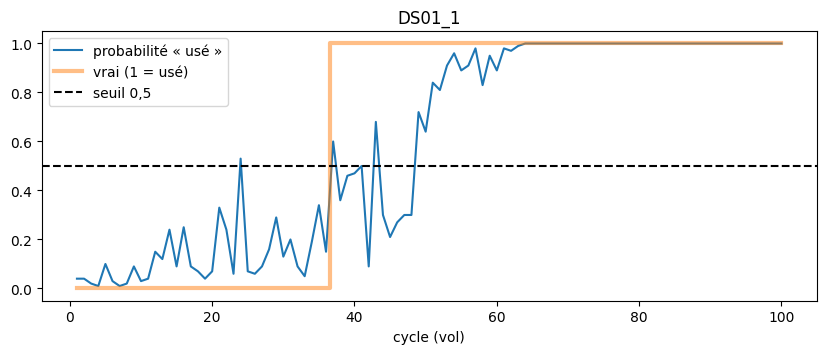

In [8]:
m = apercu[apercu["moteur"] == apercu["moteur"].iloc[0]]
plt.figure(figsize=(10, 3.5))
plt.plot(m["cycle"], m["proba_use"], label="probabilité « usé »")
plt.step(m["cycle"], m["vrai"], where="mid", alpha=0.5, linewidth=3, label="vrai (1 = usé)")
plt.axhline(0.5, color="black", linestyle="--", label="seuil 0,5")
plt.xlabel("cycle (vol)"); plt.legend(); plt.title(m["moteur"].iloc[0])
plt.show()

In [9]:
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier

candidats = {
    "bete (toujours la classe majoritaire)": DummyClassifier(strategy="most_frequent"),
    "copieur (KNN, 5 voisins)": make_pipeline(StandardScaler(), KNeighborsClassifier(5)),
    "regression logistique": logistique,
}
for nom, modele in candidats.items():
    modele.fit(X_train, y_train)
    scores = taux_par_classe(y_val, modele.predict(X_val))
    ajouter_au_leaderboard(LEADERBOARD, nom, {k: round(v, 3) for k, v in scores.items()})

pd.read_csv(LEADERBOARD)

,modele,exactitude,uses_detectes,sains_reconnus
0,bete (toujours la classe majoritaire),0.702,1.000,0.000
1,"copieur (KNN, 5 voisins)",0.799,0.843,0.693
2,regression logistique,0.905,0.932,0.840
